# 🔒 SIREN 用于真实 PII 数据：方法是否有效？能否分出 PII 类别？

复现 ACL 2026 论文 arXiv:2604.18519 的方法（逐层 L1 探针 → 安全神经元选择 →
自适应跨层融合 → MLP 分类头），换到 PII 数据上，问两个问题：

1. **二分类**：这套方法能判断一段文本里有没有个人信息吗？
2. **多分类**：能进一步分出具体是哪一类 PII 吗？

| | 内容 |
|---|---|
| **前置** | 构建数据集：正样本 + 负样本从哪来，以及怎么验证这份数据没问题 |
| **实验一** | 二分类 —— 论文的方法对 PII 有效吗？ |
| **实验二** | 多分类 —— 能分出具体是哪一类 PII 吗？ |
| **实验三** | 换一组「标识符类型」重跑多分类（cap 提到 60000） |
| **实验四** | 换用末位词元池化，检验层级形状是否复现 |
| **实验五** | 换层内取点，改取归一化后的状态 |
| **附录** | 同源语料的两个二分类变体，作为参照 |


## 步骤 1：环境检查、克隆仓库与安装依赖

In [2]:
!nvidia-smi

# 始终同步到远端最新代码。
# 注意 os.chdir('/content')：本 cell 末尾的 %cd 会切进仓库目录，若重复运行本 cell
# 而不先回到 /content，isdir 判断会失败并在仓库内再克隆一层嵌套目录。
import os
os.chdir('/content')
REPO = 'siren-pii-probing'
if os.path.isdir(REPO):
    !cd $REPO && git fetch -q origin && git reset -q --hard origin/main
else:
    !git clone -q https://github.com/jackyluo-learning/siren-pii-probing.git
%cd /content/$REPO
!git log --oneline -1      # 确认拿到的是哪个提交

!pip install --quiet torch transformers scikit-learn matplotlib datasets tqdm scipy

Thu Aug 27 14:47:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   36C    P8             13W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 前置：构建数据集 —— 正负样本从哪来

**正样本**取自 `ai4privacy/pii-masking-200k`。每一行是一个自然句子，外加 `privacy_mask`
标注了句中每一段个人信息的位置和类别（52 个类别：SSN、EMAIL、CREDITCARDNUMBER、IPV4…）。

**负样本是个麻烦**：这个语料**每一行都含 PII**（实测 3000 行里 0 行 `privacy_mask` 为空）——
它本来就是为训练掩码模型造的，没有干净文本可用。两种就地制造干净负样本的办法都被否掉了：

| 做法 | 产出 | 为什么不行 |
|---|---|---|
| 按 span 删掉 PII | `"Dear , as per our records, your license  is still registered"` | 残缺句式成了新提示词，探针学「句子断没断」 |
| 用 `target_text` | `"Dear [FIRSTNAME], your license [VEHICLEVIN] …"` | `[FIRSTNAME]` 是字面标记，更明显 |

这不是洁癖。这个项目早期版本用手写模板，正样本 *"SSN is 492-10-4921"*、
负样本 *"Order ID is 492-10-4921"*，探针在**第 1 层就 F1 = 1.000**——
一个提示词就把两类分开了，整个实验毫无意义。

### 所以：从 4 个公开语料导入干净负样本

banking77 / dolly-instruction / dolly-response / ag_news，共 24333 条可用，加三道防护：

1. **多来源** —— 不让单一风格定义「干净」
2. **词数带对齐 13–40 词** —— 与正样本的 5%~95% 分位一致，长度不能当线索
3. **正则筛** —— 丢掉残留标识符，以及 `{{Order Number}}`、`[EMAIL]` 这类模板标记

### 怎么知道这份数据没问题：词袋基线

跨语料合并绕不开一个问题：两个语料库的差别**不只是有没有 PII，还有词汇和文体**。
所以每个任务都先量一条**地板线**——用 TF-IDF 词袋（只数词频、完全不懂语义）能拿到多少分。
**探针必须明显高过这条线，结果才说明表示层真的编码了 PII。**

下面两个 cell 都在 CPU 上跑、不加载模型：

- **第一个**先扫一遍语料，看有哪些 PII 类别、各自多常见——实验二、三选类别的依据；
- **第二个**是数据体检，把所有任务的规模和词袋地板线一次列出。


In [3]:
!PYTHONPATH=.:examples python -u examples/run_pii_layerwise.py --task survey --cap 4000

SIREN on real PII data — task=survey | model=Qwen/Qwen3-4B | device=cuda
README.md: 100% 14.1k/14.1k [00:00<00:00, 33.1MB/s]
扫描 4000 条文本，共出现 56 个 PII 类别。前 30 个：
    FIRSTNAME               1195  ( 29.9% 的文本含有)
    LASTNAME                 443  ( 11.1% 的文本含有)
    DATE                     409  ( 10.2% 的文本含有)
    EMAIL                    339  (  8.5% 的文本含有)
    PREFIX                   304  (  7.6% 的文本含有)
    ACCOUNTNUMBER            288  (  7.2% 的文本含有)
    AMOUNT                   284  (  7.1% 的文本含有)
    ACCOUNTNAME              281  (  7.0% 的文本含有)
    JOBAREA                  273  (  6.8% 的文本含有)
    CURRENCYSYMBOL           273  (  6.8% 的文本含有)
    TIME                     272  (  6.8% 的文本含有)
    USERNAME                 269  (  6.7% 的文本含有)
    URL                      260  (  6.5% 的文本含有)
    JOBTITLE                 257  (  6.4% 的文本含有)
    CREDITCARDNUMBER         256  (  6.4% 的文本含有)
    MIDDLENAME               255  (  6.4% 的文本含有)
    STREET                   249  (  6.2% 的文本含有)
    IP

In [4]:
# 数据体检：各任务规模 + 词袋地板线（CPU，约 1 分钟，不加载模型）
!PYTHONPATH=.:examples python -u examples/pii_data_report.py --cap 6000 --per-source 1500


PII 数据体检 —— 各任务的规模，以及词袋模型已经能解决多少
README.md: 100% 16.6k/16.6k [00:00<00:00, 41.4MB/s]

data/train-00000-of-00001.parquet: downloading bytes:   0% 0.00/294k [00:00<?, ?B/s]
data/train-00000-of-00001.parquet: downloading bytes: 100% 288k/288k [00:00<00:00, 421kB/s, 28.5kB/s  ]
data/train-00000-of-00001.parquet: reconstructing file: 100% 294k/294k [00:00<00:00, 430kB/s, 29.1kB/s  ]

data/test-00000-of-00001.parquet: downloading bytes:   0% 0.00/91.4k [00:00<?, ?B/s]
data/test-00000-of-00001.parquet: downloading bytes: 100% 90.2k/90.2k [00:00<00:00, 171kB/s, 8.94kB/s  ]
data/test-00000-of-00001.parquet: reconstructing file: 100% 91.4k/91.4k [00:00<00:00, 173kB/s, 9.05kB/s  ]
Generating train split: 100% 9993/9993 [00:00<00:00, 415340.59 examples/s]
Generating test split: 100% 3076/3076 [00:00<00:00, 896510.26 examples/s]
README.md: 100% 8.20k/8.20k [00:00<00:00, 24.5MB/s]

databricks-dolly-15k.jsonl: downloading bytes:  46% 5.97M/13.1M [00:00<00:00, 9.32MB/s]
databricks-dolly-15k.jsonl: dow

## 实验一：二分类 —— 论文的方法对 PII 有效吗？

任务：**这段文本里有没有个人信息？** 正样本来自 ai4privacy，负样本来自 4 个干净语料。

体检结果会显示，**直接混合的词袋地板线高达 0.96**——词袋倚重的是
`reuters`、`ap`（ag_news 的通讯社署名）、`what`/`how`（banking77 和 dolly 的提问句式）、
`our`/`your`/`dear`（ai4privacy 的商务信函腔）。**没有一个词和 PII 有关**，
它认的是「这句话出自哪个语料库」。这种情况下探针就算拿到 0.99 也说明不了什么。

**解法：留出一个训练时完全没见过的语料。**
`--holdout-source banking77` 把 banking77 整个排除出训练，测试集的负样本**全部**取自它。
表面词汇不再够用，地板线掉到 **0.797**——探针必须学到「这句话里没有标识符」，
而不是「这句话不是那几个语料写的」。

### 留出两个语料，不是一个

第一版只留出测试语料，验证集的负样本仍来自训练语料——结果 36 层的 val 全挤在
**0.993–0.999**，而 test 只有 0.65–0.87。这个落差正是语料捷径本身，但它同时打坏了两件事：

- **C 的选择失效**：四个 C 值在验证集上的差异落在小数点后第四位，选出来的是噪声
- **SIREN 融合被架空**：α_l 由验证集 F1 决定（论文 Eq 5），所有层都 0.998 时 α_l 退化成均匀权重

所以现在验证集也用一个**未见语料**（默认 `ag_news`），且与测试语料（`banking77`）**不同**——
val 才对 test 有代表性，而 C 又不会被调到测试语料上：

| | 负样本来源 |
|---|---|
| 训练 | dolly_instr + dolly_resp |
| 验证 | ag_news（未参与训练） |
| 测试 | banking77（未参与训练，也未参与调参） |

**A 是主实验，B 是对照。** 先看 A。


SIREN on real PII data — task=presence-merged | model=Qwen/Qwen3-4B | device=cuda
    干净负样本 banking77   :  1500 条（词数 13-40，已过正则筛）
    干净负样本 dolly_instr :  1500 条（词数 13-40，已过正则筛）
    干净负样本 dolly_resp  :  1500 条（词数 13-40，已过正则筛）
    干净负样本 ag_news     :  1500 条（词数 13-40，已过正则筛）
二分类任务「是否含 PII」：正样本来自 ai4privacy，负样本来自 ['ag_news', 'banking77', 'dolly_instr', 'dolly_resp']
  留出语料: 训练负样本=['dolly_instr', 'dolly_resp'] | 验证负样本=ag_news | 测试负样本=banking77
  验证与测试各用一个未见语料，C 与 alpha_l 才有区分度，且不会调到测试语料上
  ⚠️ 跨语料任务的 TF-IDF 词袋下限实测 0.981（同源任务仅 0.755），请把探针分数与词袋基线并列解读

数据划分: train 6000 / val 1656 / test 1656 | 类别数 2
示例: "In reference to your recent orthopedic procedures, 5876845660353528, we've updated our records for 3NgRJZWk3GB" -> contains PII

先量表面词汇下限（几秒，不用 GPU）...
  TF-IDF 词袋基线（表面词汇下限）: Macro-F1 = 0.7851
Loading 'Qwen/Qwen3-4B' on cuda ...
config.json: 100% 726/726 [00:00<00:00, 4.40MB/s]
tokenizer_config.json: 100% 9.73k/9.73k [00:00<00:00, 27.3MB/s]
vocab.json: 100% 2.78M/2.78M [00:00<00:00, 111MB/s]
m

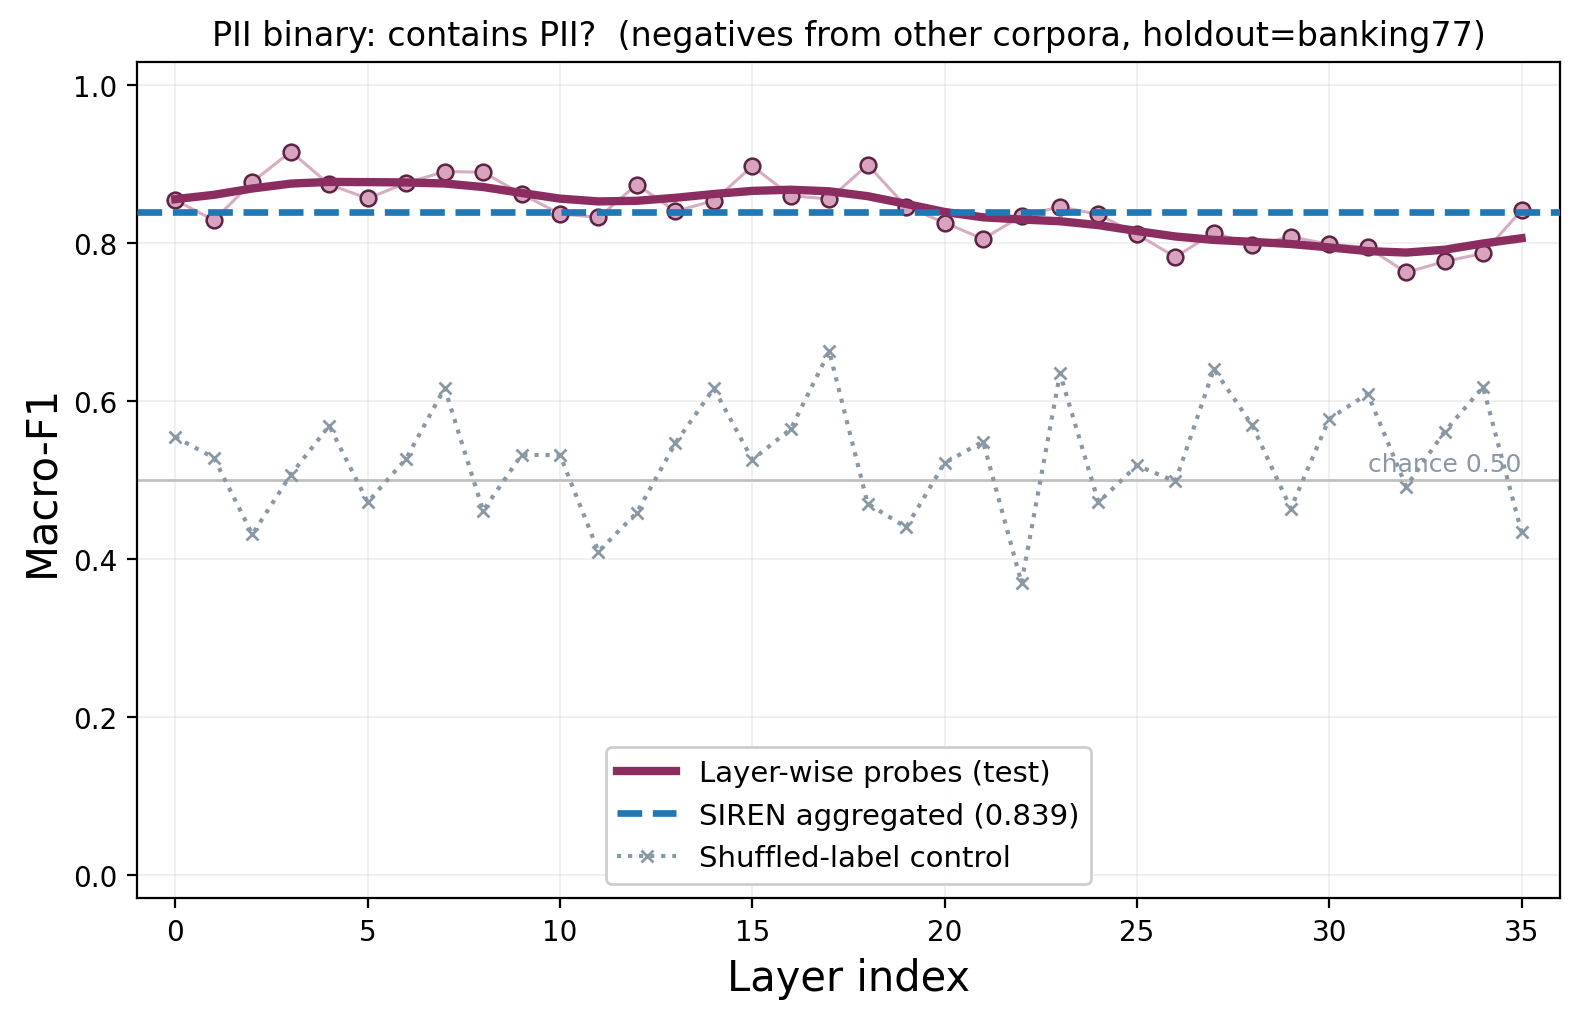

In [ ]:
# A（主实验）：留出 banking77 —— 地板线 0.797，有真实解读空间
!PYTHONPATH=.:examples python -u examples/run_pii_layerwise.py \
    --task presence-merged --holdout-source banking77 \
    --model "Qwen/Qwen3-4B" --cap 6000 --per-source 1500 --max-length 128 \
    --out-prefix pii

from IPython.display import Image, display
display(Image('pii_presence_merged_ho_banking77_layers.png'))


SIREN on real PII data — task=presence-merged | model=Qwen/Qwen3-4B | device=cuda
    干净负样本 banking77   :  1500 条（词数 13-40，已过正则筛）
    干净负样本 dolly_instr :  1500 条（词数 13-40，已过正则筛）
    干净负样本 dolly_resp  :  1500 条（词数 13-40，已过正则筛）
    干净负样本 ag_news     :  1500 条（词数 13-40，已过正则筛）
二分类任务「是否含 PII」：正样本来自 ai4privacy，负样本来自 ['ag_news', 'banking77', 'dolly_instr', 'dolly_resp']
  ⚠️ 跨语料任务的 TF-IDF 词袋下限实测 0.981（同源任务仅 0.755），请把探针分数与词袋基线并列解读

数据划分: train 7732 / val 1656 / test 1656 | 类别数 2
示例: "Dear Prince, I've come across a brilliant business opportunity in the Creative sector. The plan involves expan" -> contains PII

先量表面词汇下限（几秒，不用 GPU）...
  TF-IDF 词袋基线（表面词汇下限）: Macro-F1 = 0.9819
Loading 'Qwen/Qwen3-4B' on cuda ...
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100% 398/398 [00:02<00:00, 160.82it/s]
Detected 36 transformer layers.

抽取 mean-pooled 表征（36 层）...
pooling: 开始，共 484 批
pooling: 1/484 (0%)  已用 0s  剩余约 6m40s
pooling: 25/484 (5%)  已用 10s  剩余约 3m06s
pooling: 50

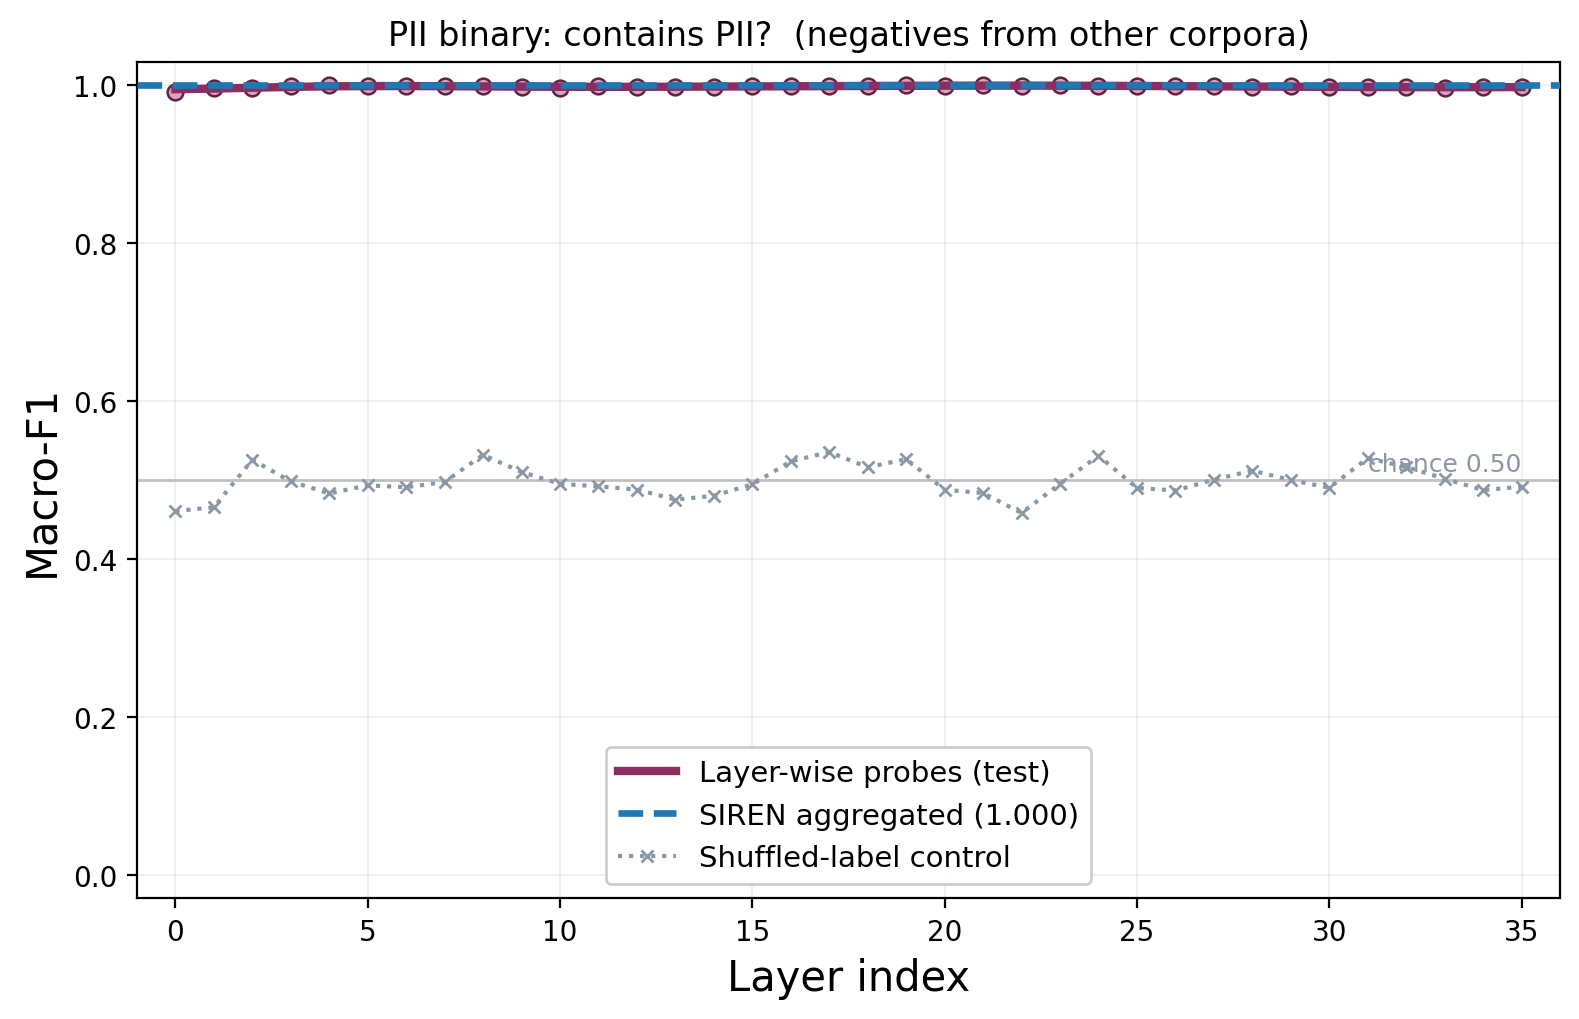

In [ ]:
# B（对照）：直接混合 —— 地板线 0.96，用来对比「不留出会怎样」
!PYTHONPATH=.:examples python -u examples/run_pii_layerwise.py \
    --task presence-merged \
    --model "Qwen/Qwen3-4B" --cap 6000 --per-source 1500 --max-length 128 \
    --out-prefix pii

from IPython.display import Image, display
display(Image('pii_presence_merged_layers.png'))


## 实验二：多分类 —— 能分出具体是哪一类 PII 吗？

任务：**这段文本携带的是哪一类 PII？**

只保留**恰好含一个**目标类别的文本，让标签无歧义；同时含多个目标类别的文本会被丢弃（脚本会报告丢弃数量，代价是可见的）。

这是比实验 1 更强的检验：所有样本来自同一语料、同一文风、同一生成器，**唯一的差别就是标识符的种类**。要做对，模型的内部表征必须真的把"社保号"和"信用卡号"编码成不同的东西。

产出两张图：**层级曲线**（看哪一层最能区分类别）与**混淆矩阵**（看哪些类别之间容易混淆）。

SIREN on real PII data — task=multiclass | model=Qwen/Qwen3-4B | device=cuda
未指定类别，按频次自动选取 6 个：['FIRSTNAME', 'LASTNAME', 'DATE', 'EMAIL', 'PREFIX', 'AMOUNT']
多分类任务：6 类 × 每类 162 条 = 972 条
  丢弃：同时含多个目标类别 3731 条；不含任何目标类别 10285 条
  类别：['FIRSTNAME', 'LASTNAME', 'DATE', 'EMAIL', 'PREFIX', 'AMOUNT']

数据划分: train 682 / val 145 / test 145 | 类别数 6
示例: 'Dear Jada, your next assignment at Apt. 787, make sure to use VPN with IP 178.179.101.4 for secure connection ' -> FIRSTNAME

先量表面词汇下限（几秒，不用 GPU）...
  TF-IDF 词袋基线（表面词汇下限）: Macro-F1 = 0.6190
Loading 'Qwen/Qwen3-4B' on cuda ...
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100% 398/398 [00:02<00:00, 160.16it/s]
Detected 36 transformer layers.

抽取 mean-pooled 表征（36 层）...
pooling: 开始，共 43 批
pooling: 1/43 (2%)  已用 0s  剩余约 39s
pooling: 3/43 (7%)  已用 1s  剩余约 24s
pooling: 6/43 (14%)  已用 3s  剩余约 19s
pooling: 9/43 (21%)  已用 4s  剩余约 16s
pooling: 12/43 (28%)  已用 5s  剩余约 15s
pooling: 15/43 (35%)  已用 7s  剩余约 13s
pooling: 18/4

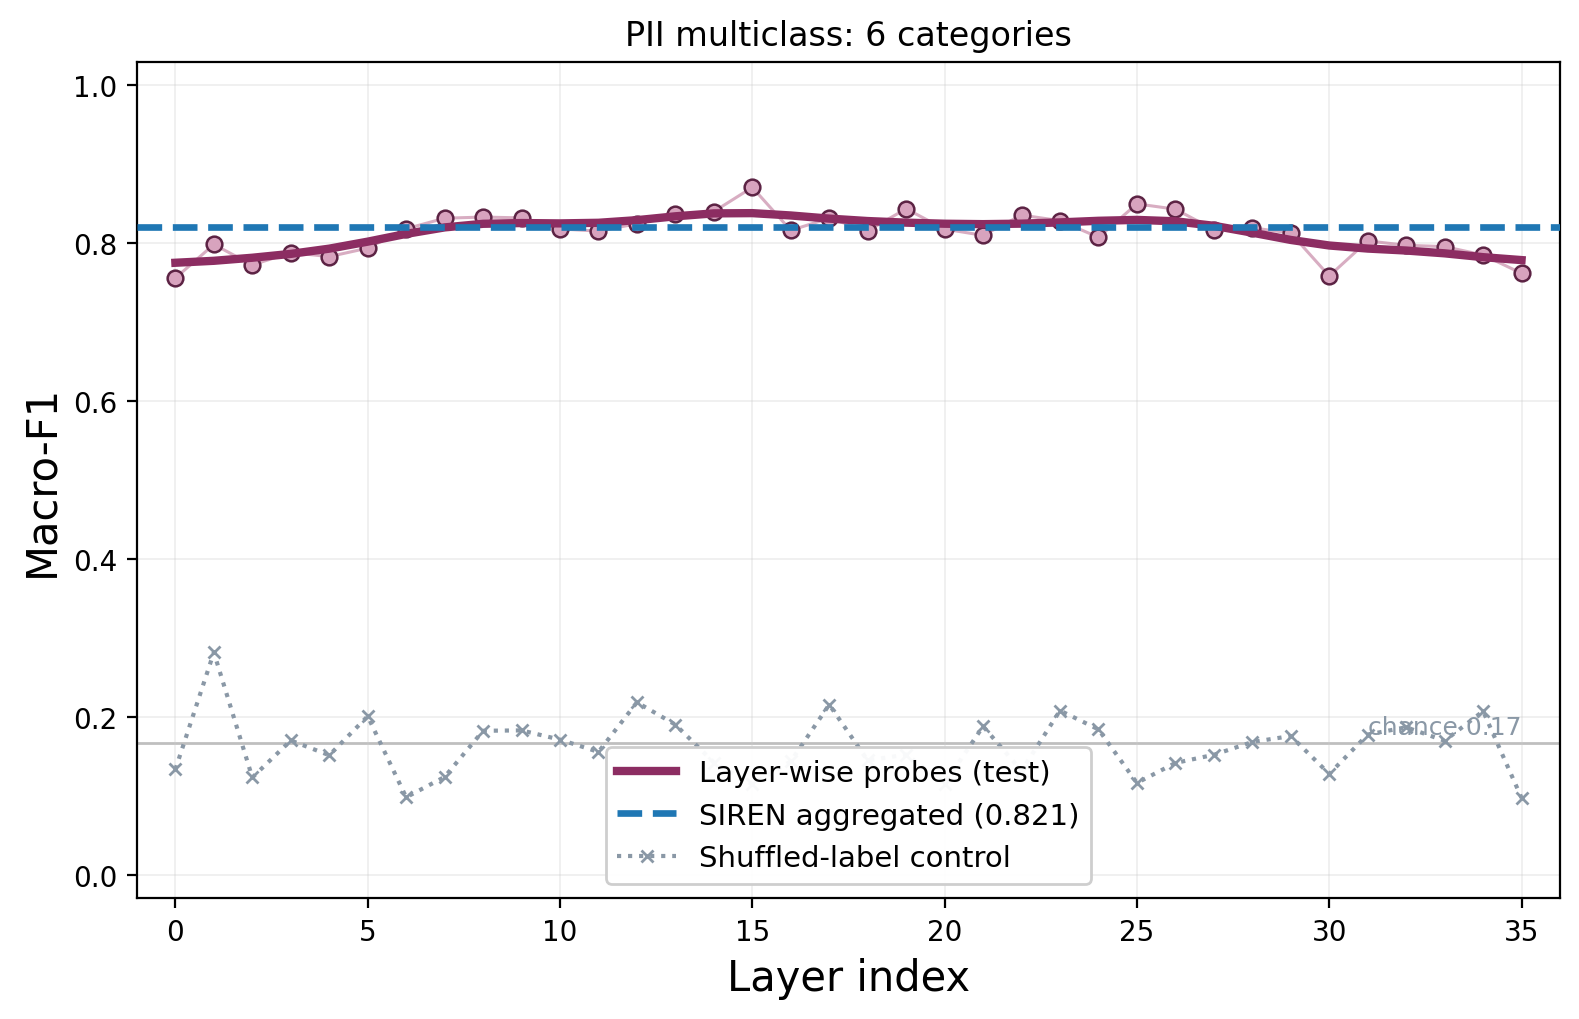

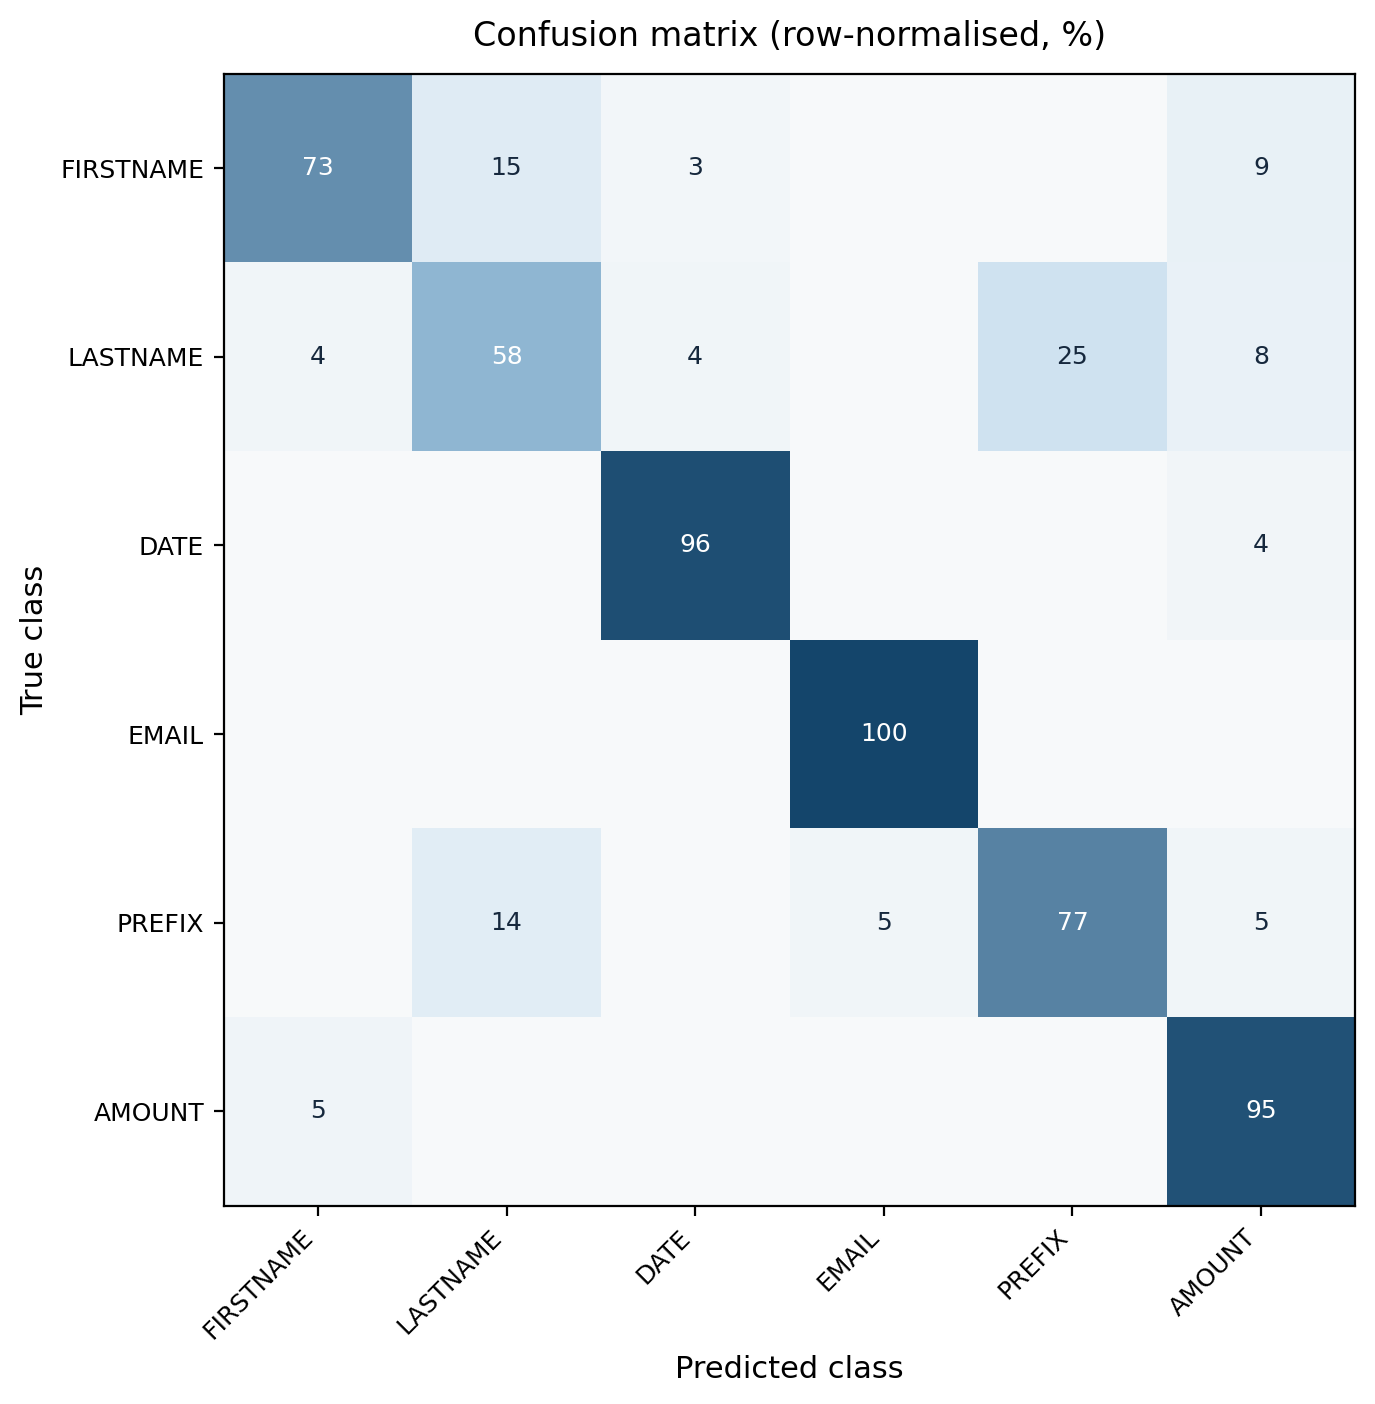

In [ ]:
# 不指定 --categories 则按频次自动取前 N 个类别。
# 也可显式指定一组「标识符类型差异明显」的类别，例如：
#   --categories "EMAIL,SSN,CREDITCARDNUMBER,IPV4,PHONENUMBER,IBAN"
# 注意用数据集的真实标签名（SSN 不是 SOCIALNUM，PHONENUMBER 不是 TELEPHONENUM）。
!PYTHONPATH=.:examples python -u examples/run_pii_layerwise.py \
    --task multiclass --n-categories 6 \
    --model "Qwen/Qwen3-4B" --cap 20000 --min-per-class 80 --max-length 128

from IPython.display import Image, display
display(Image('pii_multiclass_6way_layers.png'))
display(Image('pii_multiclass_6way_confusion.png'))

## 实验三：换一组「标识符类型」重跑多分类（cap 提到 60000）

实验 2 自动按频次选出的六类是 `FIRSTNAME / LASTNAME / DATE / EMAIL / PREFIX / AMOUNT`，其中**三个是人名成分**（名、姓、称谓 Mr./Dr.）——它们在文本里常常紧挨着出现、语义高度重叠，`LASTNAME` 的 F1 只有 0.622，几乎可以肯定是和 `FIRSTNAME` 混淆了。

这等于把问题问偏了：一半类别在考「人名的细分」，另一半在考「格式化标识符」，两者难度完全不同，混在一起看不出模型到底把 PII 类型编码到什么精度。

本实验改用**六种彼此不同的标识符类型**，每一种都有独立的格式与用途：

| 类别 | 是什么 | 语料占比 |
|---|---|---|
| `EMAIL` | 邮箱地址 | 8.5% |
| `CREDITCARDNUMBER` | 信用卡号 | 6.4% |
| `IPV4` | IP 地址 | 6.1% |
| `ACCOUNTNUMBER` | 账号 | 7.2% |
| `PASSWORD` | 密码 | 5.7% |
| `BITCOINADDRESS` | 比特币地址 | 5.5% |

同时把 `--cap` 从 20000 提到 **60000**。实验 2 因为「只保留恰好含一个目标类别」的过滤，最终每类仅 162 条、train 只有 682 条——**样本量远小于 z 维度（31656）**，这很可能就是 SIREN 融合反而比最佳单层低 0.05 的原因（融合头在小样本上过拟合）。加大 cap 是检验这个猜测的直接办法。

> 输出文件用 `--out-prefix pii_ids` 区分，不会覆盖实验 2 的图。
>
> ⏱️ cap 60000 意味着要流式扫描 6 万行原始数据，加上更多样本的前向抽取，**耗时明显长于实验 2**。

SIREN on real PII data — task=multiclass | model=Qwen/Qwen3-4B | device=cuda
多分类任务：6 类 × 每类 1991 条 = 11946 条
  丢弃：同时含多个目标类别 1496 条；不含任何目标类别 27934 条
  类别：['EMAIL', 'CREDITCARDNUMBER', 'IPV4', 'BITCOINADDRESS', 'ACCOUNTNUMBER', 'PASSWORD']

数据划分: train 8364 / val 1791 / test 1791 | 类别数 6
示例: "This is a kind reminder about the speech competition starting on 23/08/2013. It's important that every partici" -> EMAIL

先量表面词汇下限（几秒，不用 GPU）...
  TF-IDF 词袋基线（表面词汇下限）: Macro-F1 = 0.8454
Loading 'Qwen/Qwen3-4B' on cuda ...
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100% 398/398 [00:02<00:00, 159.05it/s]
Detected 36 transformer layers.

抽取 mean-pooled 表征（36 层）...
pooling: 开始，共 523 批
pooling: 1/523 (0%)  已用 1s  剩余约 9m28s
pooling: 27/523 (5%)  已用 12s  剩余约 3m54s
pooling: 54/523 (10%)  已用 24s  剩余约 3m35s
pooling: 81/523 (15%)  已用 35s  剩余约 3m15s
pooling: 108/523 (21%)  已用 47s  剩余约 3m03s
pooling: 135/523 (26%)  已用 59s  剩余约 2m49s
pooling: 162/523 (31%)  已用 1m09s  剩余约 2m3

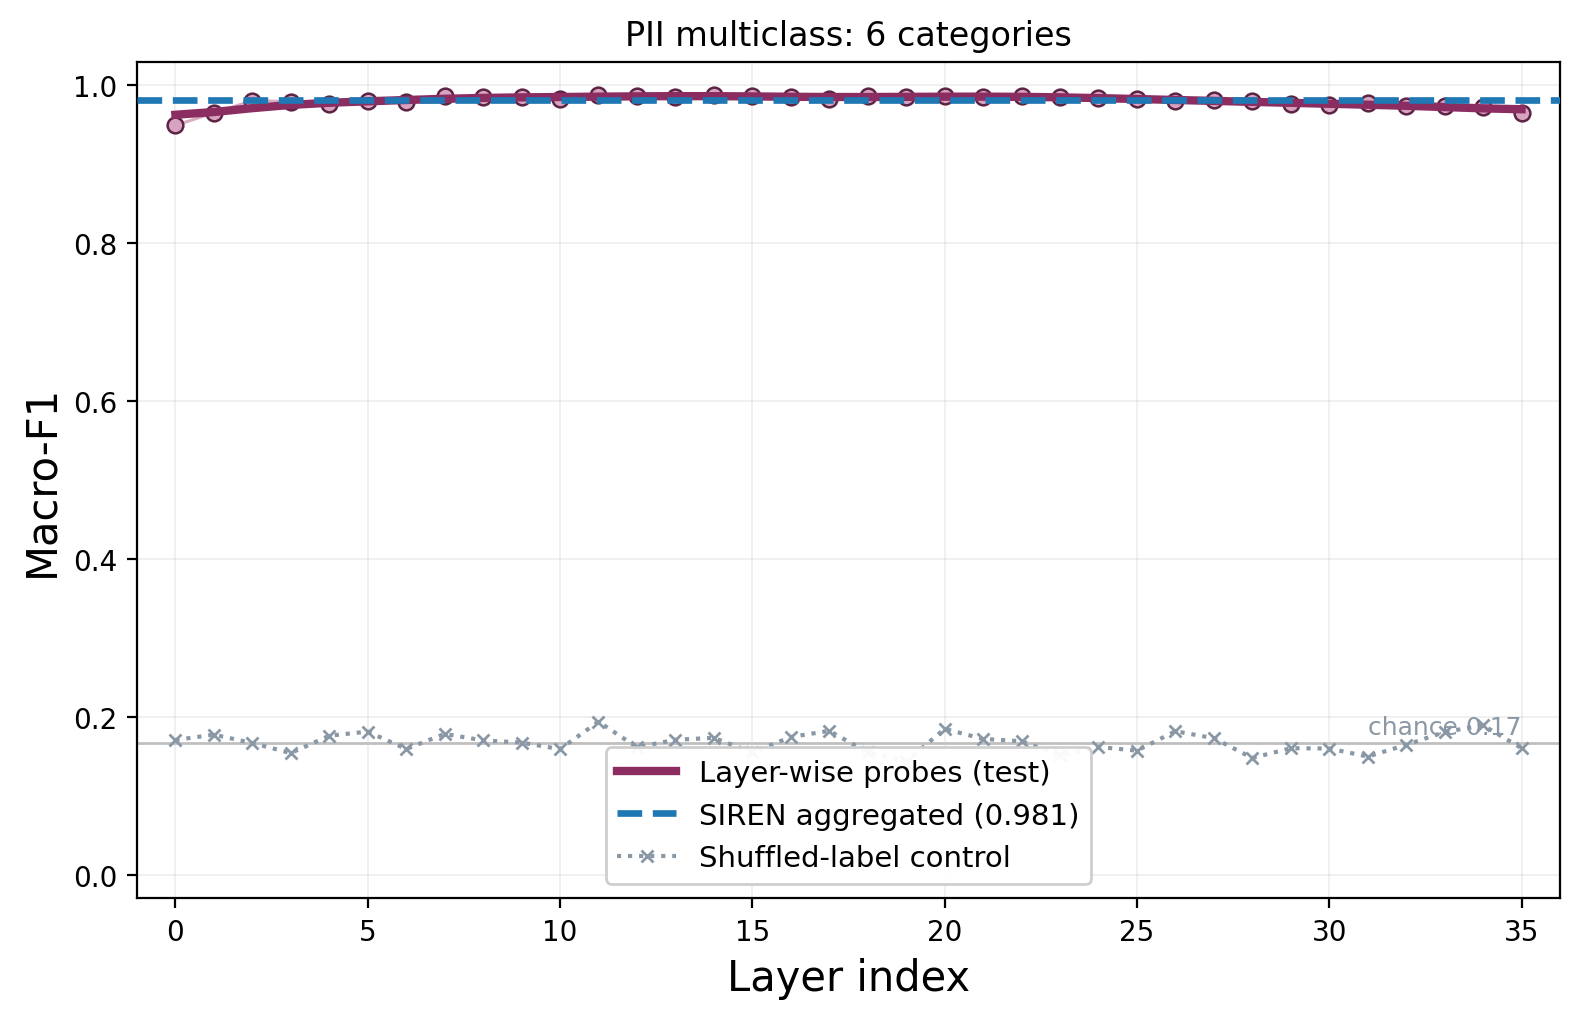

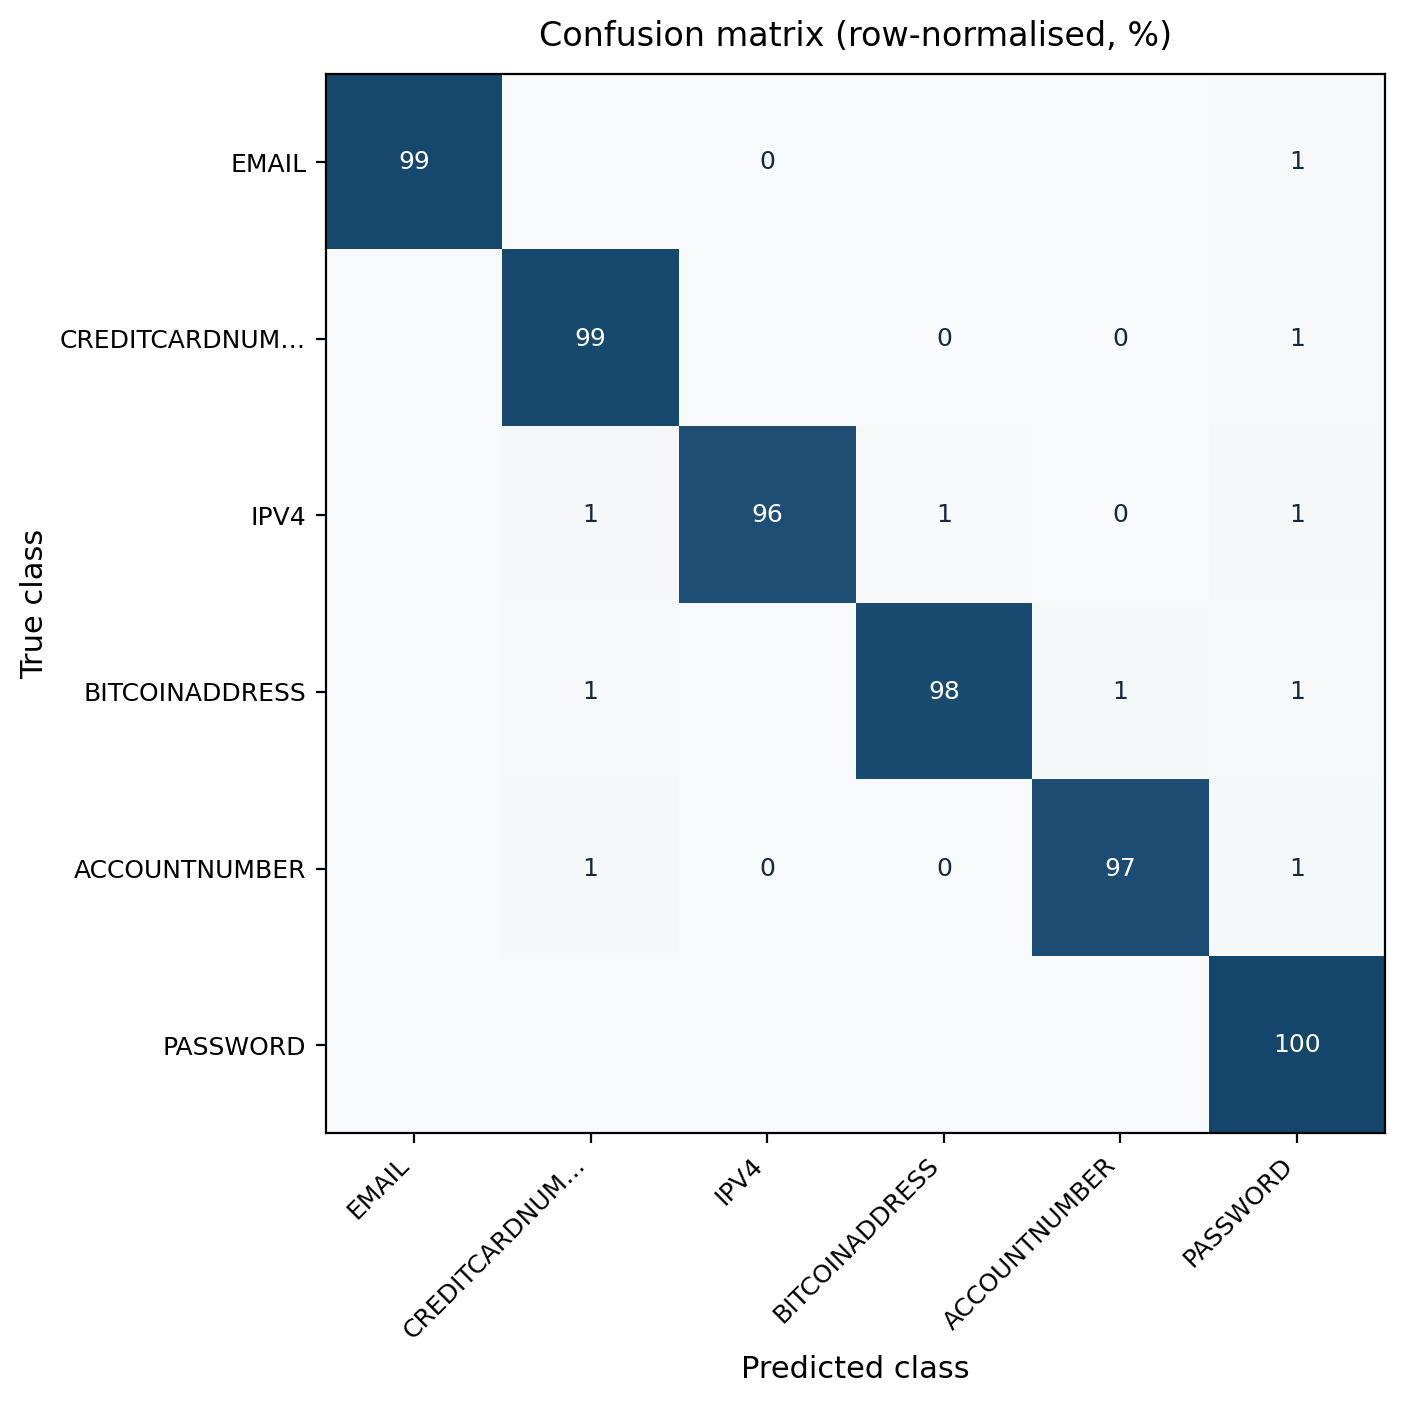

In [ ]:
!PYTHONPATH=.:examples python -u examples/run_pii_layerwise.py \
    --task multiclass \
    --categories "EMAIL,CREDITCARDNUMBER,IPV4,BITCOINADDRESS,ACCOUNTNUMBER,PASSWORD" \
    --model "Qwen/Qwen3-4B" --cap 60000 --min-per-class 80 --max-length 128 \
    --out-prefix pii_ids

from IPython.display import Image, display
display(Image('pii_ids_multiclass_6way_layers.png'))
display(Image('pii_ids_multiclass_6way_confusion.png'))

## 实验四：换一种句表征方式 —— 末位词元池化能复现同样的层级形状吗？

前面全部实验都用**均值池化**（论文 Eq. 2）：把一句话在某一层的所有词元表征按位置取平均。
这是论文的做法，但不是唯一合理的做法。

因果语言模型是从左往右读的，**只有最后一个词元「读完了整句话」**——
所以取末位词元的表征也是句表征的标准选择之一（很多检索与分类工作就这么做）。

这个实验把实验一A 原样重跑一遍，**只改池化方式**，其余全部不变：同样的数据划分、
同样的留出语料、同样的 C 网格与 η。要回答的是：

> 实验一A 观察到的「早层强、深层塌」的形状，是**表征本身**的性质，
> 还是**均值池化**这一种取法带来的？

两种可能的结果都有意义：

- **形状复现** → 说明那是分布偏移下表征的普遍性质，与怎么取句向量无关，结论更稳；
- **形状消失** → 说明它是均值池化的产物。这也解释得通：均值池化会把
  「注意力汇聚点」（首个词元的巨大激活）混进每一层的句向量，而末位词元池化不会。

图和 JSON 会写到 `pii_presence_merged_ho_banking77_last_*`，不会覆盖实验一A 的均值池化结果，
方便直接对比。


SIREN on real PII data — task=presence-merged | model=Qwen/Qwen3-4B | device=cuda
    干净负样本 banking77   :  1500 条（词数 13-40，已过正则筛）
    干净负样本 dolly_instr :  1500 条（词数 13-40，已过正则筛）
    干净负样本 dolly_resp  :  1500 条（词数 13-40，已过正则筛）
    干净负样本 ag_news     :  1500 条（词数 13-40，已过正则筛）
二分类任务「是否含 PII」：正样本来自 ai4privacy，负样本来自 ['ag_news', 'banking77', 'dolly_instr', 'dolly_resp']
  留出语料: 训练负样本=['dolly_instr', 'dolly_resp'] | 验证负样本=ag_news | 测试负样本=banking77
  验证与测试各用一个未见语料，C 与 alpha_l 才有区分度，且不会调到测试语料上
  ⚠️ 跨语料任务的 TF-IDF 词袋下限实测 0.981（同源任务仅 0.755），请把探针分数与词袋基线并列解读

数据划分: train 6000 / val 1656 / test 1656 | 类别数 2
示例: "In reference to your recent orthopedic procedures, 5876845660353528, we've updated our records for 3NgRJZWk3GB" -> contains PII

先量表面词汇下限（几秒，不用 GPU）...
  TF-IDF 词袋基线（表面词汇下限）: Macro-F1 = 0.7851
Loading 'Qwen/Qwen3-4B' on cuda ...
config.json: 100% 726/726 [00:00<00:00, 3.41MB/s]
tokenizer_config.json: 100% 9.73k/9.73k [00:00<00:00, 25.6MB/s]
vocab.json: 100% 2.78M/2.78M [00:00<00:00, 10.9MB/s]


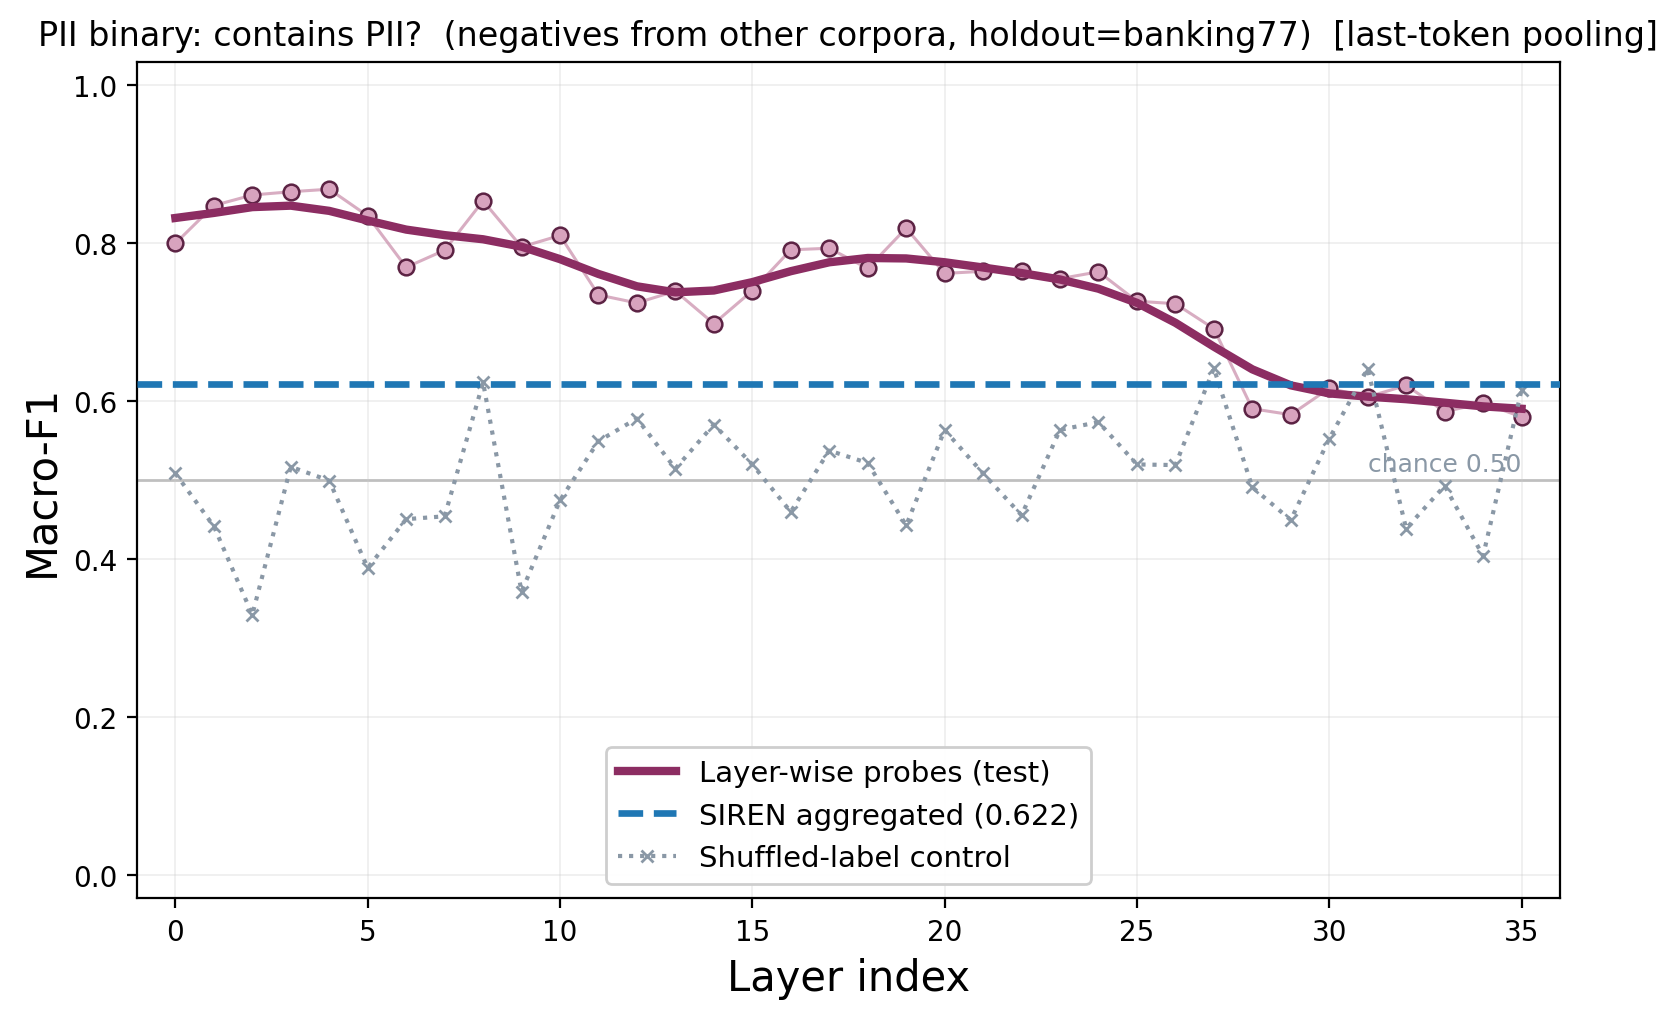

In [5]:
# 与实验一A 完全相同，只把 --pooling 从默认的 mean 换成 last
!PYTHONPATH=.:examples python -u examples/run_pii_layerwise.py \
    --task presence-merged --holdout-source banking77 --pooling last \
    --model "Qwen/Qwen3-4B" --cap 6000 --per-source 1500 --max-length 128 \
    --out-prefix pii

from IPython.display import Image, display
display(Image('pii_presence_merged_ho_banking77_last_layers.png'))


## 实验五：换层内取点 —— 取归一化后的状态（MLP 看到的）

实验四改的是「一句话怎么变成一个向量」，实验五改的是「从每一层的**哪个位置**取状态」。
两者针对同一个问题（注意力汇聚点），路径不同。

### 当前取的是哪里

代码挂在 `model.model.layers[i]` 上取 `output[0]`，即**整个 block 的输出**——
自注意力和 MLP 的残差都已加完，等同于 HuggingFace 的 `output_hidden_states`。这是论文的做法。

Qwen/Llama 是 **pre-norm**，归一化在子层**之前**：

```
x ─┬──────────────────────────────────────────────┐
   └→ input_layernorm → self_attn ────────────────┴→(+)= h

h ─┬──────────────────────────────────────────────┐
   └→ post_attention_layernorm → mlp ─────────────┴→(+)= block 输出
      ↑ 实验五取这里                                    ↑ 论文取这里
```

`post_attention_layernorm` 这个名字有误导性：它**不是**对注意力输出做归一化，而是
**在 MLP 之前**的那个归一化，输入是「注意力子层做完残差加法之后的残差流」。
挂钩实测 `post_attention_layernorm 的输出 == MLP 的输入`（逐位相同）。
所以它的输出可以准确描述为：**这一层的 MLP 实际看到的东西**。

### 为什么值得取：它把注意力汇聚点抹平了

Qwen2.5-0.5B 第 12 层实测：

| 取点 | 首词元范数 | 其余中位数 | 比值 |
|---|---|---|---|
| block 输出（论文取点） | 1684.6 | 17.56 | **95.9×** |
| **归一化后（本实验取点）** | 27.2 | 25.77 | **1.1×** |

首词元的巨大激活在归一化后**完全被压平**。这直接关系到均值池化：
此前实测单独一个首词元贡献了均值句向量 3.2 倍的量级，去掉它方向就变了（cos 仅 0.278）。
**在归一化后的状态上做均值池化，这个问题从源头消失。**

### 取舍

归一化会**丢掉量级信息**。若「这个位置激活特别大」本身携带信号，取归一化后就抹掉了。
所以哪个取点更好是实证问题——这正是要跑的原因。

图和 JSON 写到 `..._post_ln_*`，不覆盖前面的结果。


In [ ]:
# 与实验一A 完全相同，只把层内取点从默认的 residual 换成 post_ln
!PYTHONPATH=.:examples python -u examples/run_pii_layerwise.py \
    --task presence-merged --holdout-source banking77 --extraction-point post_ln \
    --model "Qwen/Qwen3-4B" --cap 6000 --per-source 1500 --max-length 128 \
    --out-prefix pii

from IPython.display import Image, display
display(Image('pii_presence_merged_ho_banking77_post_ln_layers.png'))


## 附录：同源语料的两个二分类变体（参照）

这两个任务的正负样本**都来自 ai4privacy**，不涉及跨语料合并，因此没有语料风格的干扰。
代价是问题变窄了——不是「有没有 PII」，而是「有没有**某一种** PII」。
它们的价值在于**地板线低**（0.71 / 0.76），留给表示层的空间大，可以和实验一互为参照。

| 变体 | 问题 | 负样本 | 词袋地板线 |
|---|---|---|---|
| `--task binary --target SSN` | 是否含 SSN？ | 含其他 PII 的句子 | 0.712 |
| `--task presence` | 是否含**直接标识符**？ | 只含准标识属性（姓名/职位/城市/日期） | 0.758 |

`presence` 那一版的负样本里有这种硬负例：
*"Miss Anderson's personal email address required for contact..."* ——
提到 "email address" 这个词却没有真实邮箱值，探针没法蒙关键词。


SIREN on real PII data — task=binary | model=Qwen/Qwen3-4B | device=cuda
二分类任务「是否含 SSN」：正 373 / 负 373（负样本均含其他 PII，非普通文本）

数据划分: train 524 / val 111 / test 111 | 类别数 2
示例: 'All students, particularly those looking to become a National Mobility Specialist, ought to practice good time' -> no SSN

先量表面词汇下限（几秒，不用 GPU）...
  TF-IDF 词袋基线（表面词汇下限）: Macro-F1 = 0.8378
Loading 'Qwen/Qwen3-4B' on cuda ...
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100% 398/398 [00:02<00:00, 158.69it/s]
Detected 36 transformer layers.

抽取 mean-pooled 表征（36 层）...
pooling: 开始，共 33 批
pooling: 1/33 (3%)  已用 1s  剩余约 33s
pooling: 2/33 (6%)  已用 1s  剩余约 26s
pooling: 4/33 (12%)  已用 2s  剩余约 18s
pooling: 6/33 (18%)  已用 3s  剩余约 15s
pooling: 8/33 (24%)  已用 4s  剩余约 13s
pooling: 10/33 (30%)  已用 5s  剩余约 11s
pooling: 12/33 (36%)  已用 6s  剩余约 10s
pooling: 14/33 (42%)  已用 7s  剩余约 9s
pooling: 16/33 (48%)  已用 7s  剩余约 8s
pooling: 18/33 (55%)  已用 9s  剩余约 7s
pooling: 20/33 (61%)  已用 9s  剩余约 6s
pooling: 

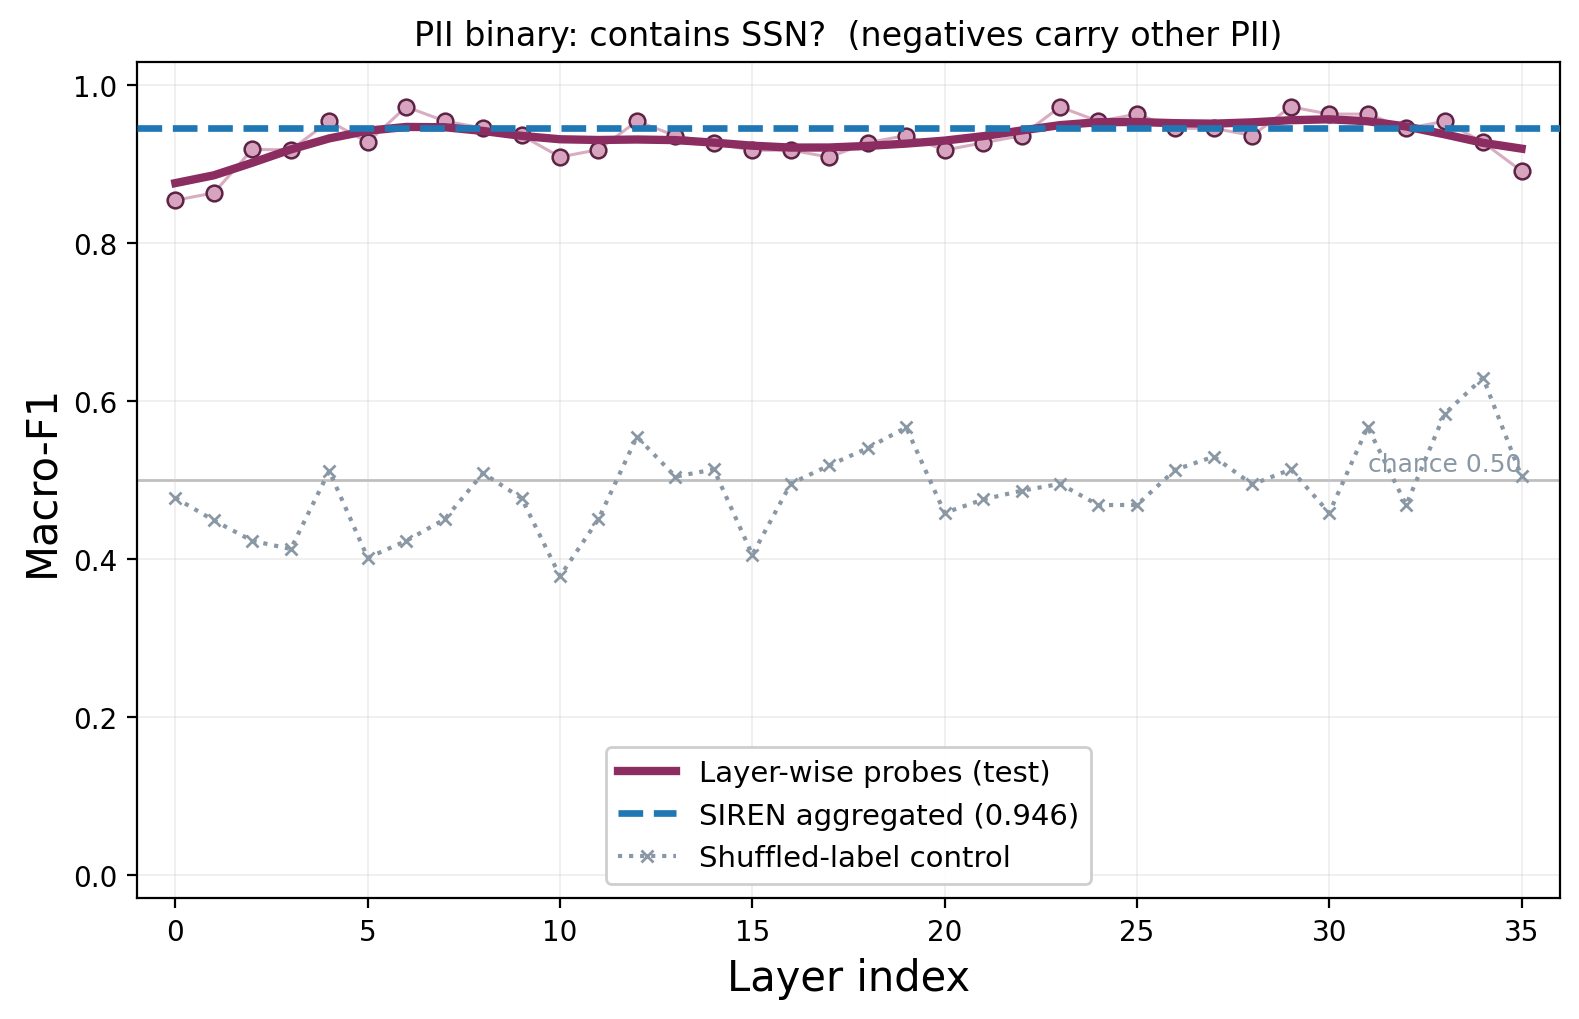

In [ ]:
# 是否含 SSN（同源语料，地板线 0.712）—— 早期版本，保留其已有结果作参照
!PYTHONPATH=.:examples python -u examples/run_pii_layerwise.py \
    --task binary --target SSN \
    --model "Qwen/Qwen3-4B" --cap 8000 --max-length 128

from IPython.display import Image, display
display(Image('pii_binary_ssn_layers.png'))

SIREN on real PII data — task=presence | model=Qwen/Qwen3-4B | device=cuda
二分类任务「是否含直接标识符」：正 2380 / 负 2380（扫描到 正 5620 / 负 2380，已平衡到较少的一侧）
  负样本并非无 PII 文本，而是只含准标识属性（姓名/职位/城市/日期等）
  正样本触发类别 Top8: ['EMAIL×687', 'USERNAME×555', 'ACCOUNTNUMBER×523', 'IPV4×494', 'CREDITCARDNUMBER×491', 'PASSWORD×466', 'BITCOINADDRESS×437', 'DOB×426']

数据划分: train 3332 / val 714 / test 714 | 类别数 2
示例: "Miss Anderson's personal email address required for contact regarding the upcoming week's schedule changes." -> quasi-identifiers only

先量表面词汇下限（几秒，不用 GPU）...
  TF-IDF 词袋基线（表面词汇下限）: Macro-F1 = 0.7913
Loading 'Qwen/Qwen3-4B' on cuda ...
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100% 398/398 [00:02<00:00, 161.28it/s]
Detected 36 transformer layers.

抽取 mean-pooled 表征（36 层）...
pooling: 开始，共 209 批
pooling: 1/209 (0%)  已用 1s  剩余约 3m53s
pooling: 11/209 (5%)  已用 5s  剩余约 1m30s
pooling: 22/209 (11%)  已用 9s  剩余约 1m20s
pooling: 33/209 (16%)  已用 13s  剩余约 1m12s
pooling: 44/209 (21%)  

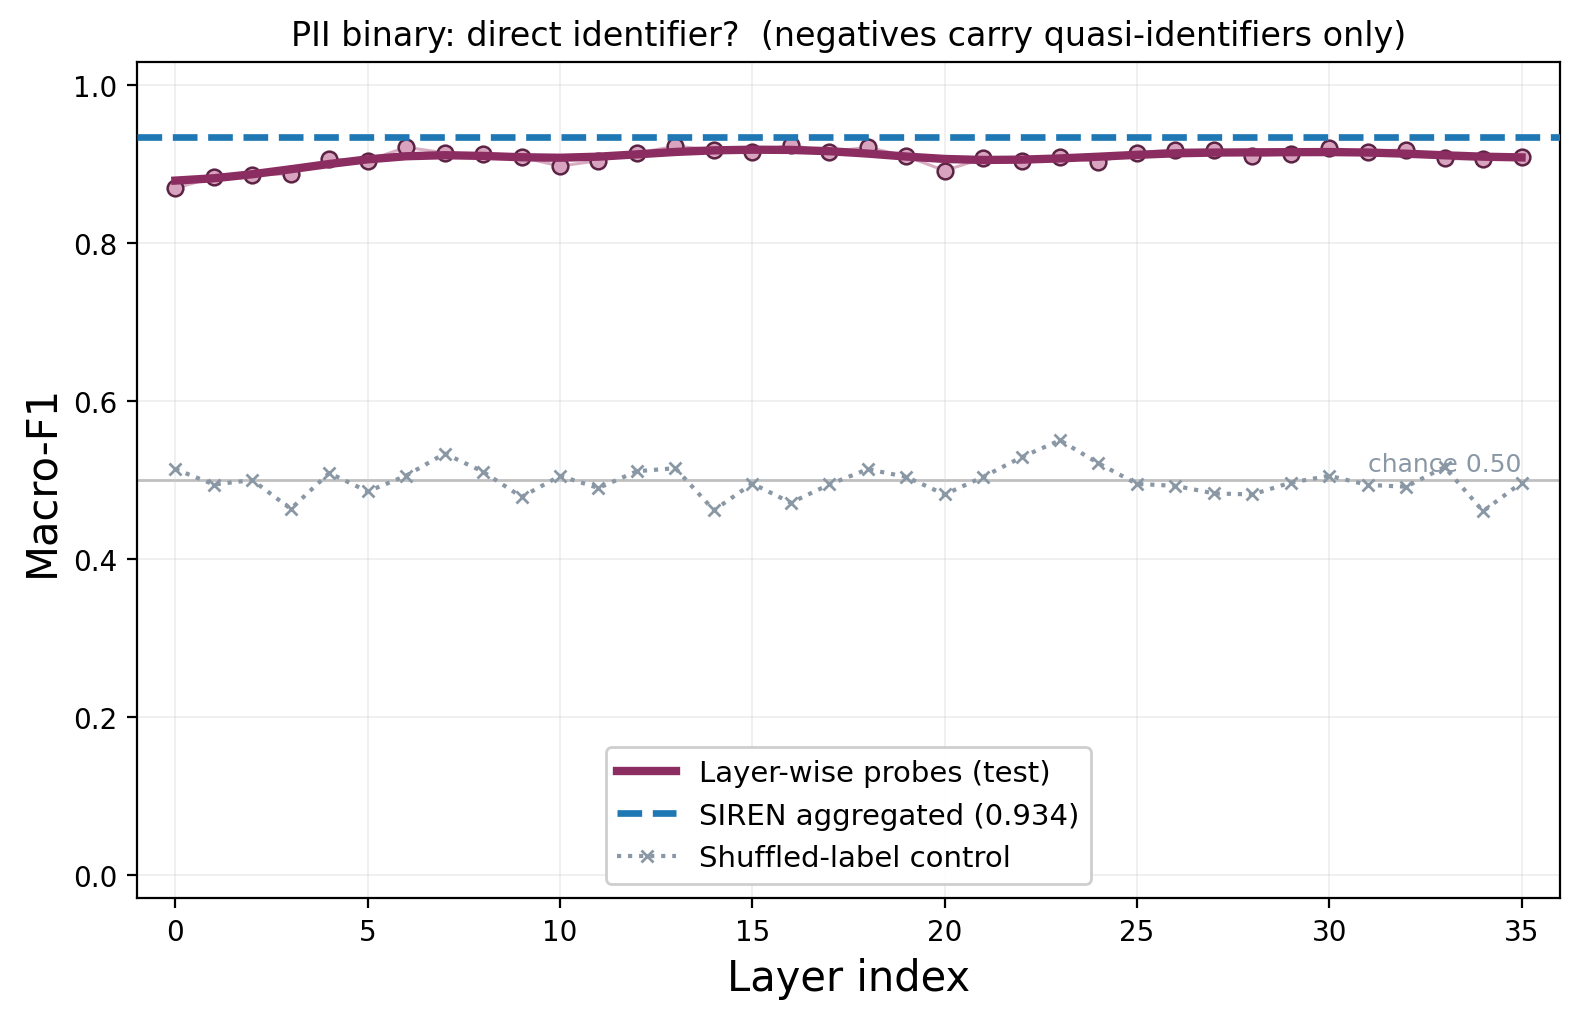

In [ ]:
# 是否含直接标识符（同源语料，地板线 0.758）
!PYTHONPATH=.:examples python -u examples/run_pii_layerwise.py \
    --task presence \
    --model "Qwen/Qwen3-4B" --cap 8000 --max-length 128 \
    --out-prefix pii

from IPython.display import Image, display
display(Image('pii_presence_layers.png'))
